# LC
 
## Fig 1. in the paper
 - Three examples for paper \
 Fig. 1 - definitely a bigger font - rule of thumb is that fonts in figures should be of comparable size with the main text;
I'd stick to python's default colors, i.e., default blue and orange - they are chosen as such to be color-blind friendly, and A&A editors pay attention to it.
I'd also add on all panels a horizontal, dashed, gray line at 10^-6 to indicate the threshold.
MJD should have units, i.e., x-axis lable should read "MJD [d]" or "MJD [days]".

# コード
## Utility: 
###  - LCファイル名一覧の取得

In [1]:
import os

def get_lc_files(dir_path_lc= "./data_LC/14d"): 
    filenames= [
        f for f in os.listdir(dir_path_lc) if os.path.isfile(os.path.join(dir_path_lc, f))
    ]
    # print(filenames)
    return filenames

In [2]:
get_lc_files()

['4fgl_j1427.9-4206_lightcurve.fits',
 '4fgl_j1512.8-0906_lightcurve.fits',
 '4fgl_j0957.6+5523_lightcurve.fits',
 '4fgl_j0428.6-3756_lightcurve.fits',
 '4fgl_j2253.9+1609_lightcurve.fits',
 '4fgl_j2232.6+1143_lightcurve.fits',
 '4fgl_j0457.0-2324_lightcurve.fits',
 '4fgl_j1833.6-2103_lightcurve.fits',
 '4fgl_j1159.5+2914_lightcurve.fits',
 '4fgl_j0721.9+7120_lightcurve.fits',
 '4fgl_j1504.4+1029_lightcurve.fits',
 '4fgl_j0348.6-2749_lightcurve.fits',
 '4fgl_j0210.7-5101_lightcurve.fits',
 '4fgl_j2202.7+4216_lightcurve.fits',
 '4fgl_j1104.4+3812_lightcurve.fits',
 '4fgl_j1224.9+2122_lightcurve.fits',
 '4fgl_j0112.1+2245_lightcurve.fits',
 '4fgl_j1256.1-0547_lightcurve.fits',
 '4fgl_j2158.8-3013_lightcurve.fits',
 '4fgl_j0108.6+0134_lightcurve.fits',
 '4fgl_j0538.8-4405_lightcurve.fits']

### - 天体名対応辞書作成

In [3]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit') # MacBook
  # hdu=fits.open('/home/kazuma/Workspace/Fermi/gll_psc_v35.fit') # Legion
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map] # data['ASSOC1']
  sources_blazars2 = sources2[element_map] # data['ASSOC2']
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  
  
  sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
def update_dict_sourcenames_for_drawing(dict_sourcename):
  # add the key 'assoc name for drawing' to dict_sourcename(astropy Table), which is used for drawing the SEDs.
  dict_sourcename['assoc name for drawing'] = ["not assigned"]*len(dict_sourcename)
  dict_sourcename[ 0]['assoc name for drawing']  = '3C 454.3' 
  dict_sourcename[ 1]['assoc name for drawing']  = 'Mrk 421' 
  dict_sourcename[ 2]['assoc name for drawing']  = 'BL Lac' 
  dict_sourcename[ 3]['assoc name for drawing']  = 'CTA 102' 
  dict_sourcename[ 4]['assoc name for drawing']  = '3C 279'
  dict_sourcename[ 5]['assoc name for drawing']  = 'S5 0716+71' 
  dict_sourcename[ 6]['assoc name for drawing']  = 'PKS 1424-41' 
  dict_sourcename[ 7]['assoc name for drawing']  = 'PKS 0426-380'
  dict_sourcename[ 8]['assoc name for drawing']  = 'PKS 0537-441'
  dict_sourcename[ 9]['assoc name for drawing']  = 'PKS 2155-304'
  dict_sourcename[10]['assoc name for drawing'] = 'PKS 0454-234'
  dict_sourcename[11]['assoc name for drawing'] = 'PKS 1510-089'
  dict_sourcename[12]['assoc name for drawing'] = 'PKS 1502+106'
  dict_sourcename[13]['assoc name for drawing'] = 'TON 599'
  dict_sourcename[14]['assoc name for drawing'] = 'PKS 0346-27'
  dict_sourcename[15]['assoc name for drawing'] = '4C +01.02'
  dict_sourcename[16]['assoc name for drawing'] = '4C +55.17'
  dict_sourcename[17]['assoc name for drawing'] = '4C +21.35'
  dict_sourcename[18]['assoc name for drawing'] = 'PKS 1830-211'
  dict_sourcename[19]['assoc name for drawing'] = 'PKS 0208-512'

  dict_sourcename['assoc name for SEDfile'] = ["not assigned"]*len(dict_sourcename)
  dict_sourcename[ 0]['assoc name for SEDfile']  = '3C454.3' 
  dict_sourcename[ 1]['assoc name for SEDfile']  = 'Mrk421' 
  dict_sourcename[ 2]['assoc name for SEDfile']  = 'BLLac' 
  dict_sourcename[ 3]['assoc name for SEDfile']  = 'CTA102' 
  dict_sourcename[ 4]['assoc name for SEDfile']  = '3C279'
  dict_sourcename[ 5]['assoc name for SEDfile']  = 'S50716+71' 
  dict_sourcename[ 6]['assoc name for SEDfile']  = 'PKS1424-41' 
  dict_sourcename[ 7]['assoc name for SEDfile']  = 'PKS0426-380'
  dict_sourcename[ 8]['assoc name for SEDfile']  = 'PKS0537-441'
  dict_sourcename[ 9]['assoc name for SEDfile']  = 'PKS2155-304'
  dict_sourcename[10]['assoc name for SEDfile'] = 'PKS0454-234'
  dict_sourcename[11]['assoc name for SEDfile'] = 'PKS1510-089'
  dict_sourcename[12]['assoc name for SEDfile'] = 'PKS1502+106'
  dict_sourcename[13]['assoc name for SEDfile'] = 'TON599'
  dict_sourcename[14]['assoc name for SEDfile'] = 'PKS0346-27'
  dict_sourcename[15]['assoc name for SEDfile'] = '4c+01.02'
  dict_sourcename[16]['assoc name for SEDfile'] = '4c+55.17'
  dict_sourcename[17]['assoc name for SEDfile'] = '4c+21.35'
  dict_sourcename[18]['assoc name for SEDfile'] = 'PKS1830-211'
  dict_sourcename[19]['assoc name for SEDfile'] = 'PKS0208-512'


  dict_sourcename[0:15]
  return dict_sourcename

In [5]:
dict_sourcename = update_dict_sourcenames_for_drawing(get_dict_sourcenames())
dict_sourcename[0:19]
# dict_sourcename[200:215]

# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245']# dict_sourcename[(dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245')]

4FGL name,assoc name,CLASS,index,assoc name for drawing,assoc name for SEDfile
str18,str28,str4,int64,str12,str12
4fgl_j2253.9+1609,3c_454.3,FSRQ,1,3C 454.3,3C454.3
4fgl_j1104.4+3812,mkn_421,BLL,2,Mrk 421,Mrk421
4fgl_j2202.7+4216,bl_lac,BLL,3,BL Lac,BLLac
4fgl_j2232.6+1143,cta_102,FSRQ,4,CTA 102,CTA102
4fgl_j1256.1-0547,3c_279,FSRQ,5,3C 279,3C279
4fgl_j0721.9+7120,s5_0716+71,BLL,6,S5 0716+71,S50716+71
4fgl_j1427.9-4206,pks_1424-41,FSRQ,7,PKS 1424-41,PKS1424-41
4fgl_j0428.6-3756,pks_0426-380,BLL,8,PKS 0426-380,PKS0426-380
4fgl_j0538.8-4405,pks_0537-441,BLL,9,PKS 0537-441,PKS0537-441


In [6]:
# mask = (dict_sourcename['assoc name'] == 'gb6 j1040+0617') 
mask = (dict_sourcename['4FGL name'] == '4fgl_j1040.5+0617') 
# mask = (dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749') 
dict_sourcename[mask]


4FGL name,assoc name,CLASS,index,assoc name for drawing,assoc name for SEDfile
str18,str28,str4,int64,str12,str12
4fgl_j1040.5+0617,gb6_j1040+0617,BLL,713,not assigned,not assigned


In [7]:
mask = (dict_sourcename['assoc name'] == 'txs_0506+056') 
# mask = (dict_sourcename['4FGL name'] == '4fgl_j1040.5+0617') 
dict_sourcename[mask]

4FGL name,assoc name,CLASS,index,assoc name for drawing,assoc name for SEDfile
str18,str28,str4,int64,str12,str12
4fgl_j0509.4+0542,txs_0506+056,BLL,55,not assigned,not assigned


In [8]:
mask = (dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749')
dict_sourcename[mask]
# dict_sourcename[14]
# mask
# dict_sourcename[14]['4FGL name']= '4fgl_j0348.5-2749'
# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0348.5-2749']
# dict_sourcename['4FGL name'] == '4fgl_j0348.5-2749'
# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749']


4FGL name,assoc name,CLASS,index,assoc name for drawing,assoc name for SEDfile
str18,str28,str4,int64,str12,str12
4fgl_j0348.6-2749,pks_0346-27,FSRQ,15,PKS 0346-27,PKS0346-27


# LCの描画
## 全LCの描画

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        # # Save the modified table back to a new fits file
        # lc_tab.write(os.path.join(lc_file_dir, f'modified_{file}'), overwrite=True)
        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        print(sourcename_4fgl)
        sourcename_assoc = sourceinfo['assoc name for drawing'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']
        plt.plot(lc_x,lc_y ,marker='o',label=sourcename_assoc)

# lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
# plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
plt.legend()
plt.show()
plt.tight_layout()


## 選択的に描画（明るさ順指定可能）

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

plot_refsource = True
if plot_refsource:
 # Plot the light curve of the reference source
  dict_sourcename = update_dict_sourcenames_for_drawing(get_dict_sourcenames())
  # print(dict_sourcename)
  # print(dict_sourcename[0])
  # print(dict_sourcename[0]['4FGL name'])
  # print(dict_sourcename[0]['assoc name'])
  # print(dict_sourcename[0]['index'])
  source = dict_sourcename[0]
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',color= 'red', label=source['assoc name for drawing'])



for source in dict_sourcename[11:14]:
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',label=source['assoc name for drawing'])

plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

# 1d SED描画可能性検証



In [11]:
lc_file_dir = 'data_LC/1d'
file_list = get_lc_files(lc_file_dir) 
print(file_list)
dict_source = get_dict_sourcenames()
dict_source[dict_sourcename['assoc name'] == '3c_454.3']



['4fgl_j0108.6+0134_lightcurve_all.fits', '4fgl_j1256.1-0547_lightcurve_all.fits', '4fgl_j2202.7+4216_lightcurve2.fits', '4fgl_j2253.9+1609_lightcurve_all.fits', '4fgl_j2253.9+1609_lightcurve2.fits', '4fgl_j1040.5+0617_lightcurve_30min.fits', '4fgl_j1512.8-0906_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve_2min.fits', '4fgl_j1833.6-2103_lightcurve1.fits', '4fgl_j1427.9-4206_lightcurve_all.fits', '4fgl_j1224.9+2122_lightcurve_all.fits', '4fgl_j2232.6+1143_lightcurve2.fits', '4fgl_j1159.5+2914_lightcurve_all.fits', '4fgl_j1256.1-0547_lightcurve1.fits', '4fgl_j2232.6+1143_lightcurve3.fits', '4fgl_j1833.6-2103_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve_10min.fits', '4fgl_j1256.1-0547_lightcurve2.fits', '4fgl_j2202.7+4216_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve.fits', '4fgl_j0348.6-2749_lightcurve_all.fits', '4fgl_j2232.6+1143_lightcurve_7d.fits', '4fgl_j1040.5+0617_lightcurve_1h.fits', '4fgl_j2232.6+1143_lightcurve1.fits', '4fgl_j2232.6+1143_lightcurve_all.fits',

4FGL name,assoc name,CLASS,index
str18,str28,str4,int64
4fgl_j2253.9+1609,3c_454.3,FSRQ,1


### - 1d LC ファイル読込
### - SED ecsv ファイル読込
### - 存否検索・列追加
### - 1d LC の描画

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os
lc_file_dir = 'data_LC/1d'
source = dict_source[dict_source['assoc name'] == '3c_454.3']
print(source['4FGL name'].data[0])

###########################
### Read the data       ###
###########################
# LC
lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve1.fits') # first 1050 days
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve2.fits') # second high state of 1150 days
lc_tab = Table.read(lc_filepath)

# SED
sed_filepath = 'data/3C454.3_allsed_1d_min11.ecsv' # both periods
# sed_filepath = 'data/3C454.3_allsed_1d_1_min11.ecsv' # first 1050 days
# sed_filepath = 'data/3C454.3_allsed_1d_2_min11.ecsv' # second high state of 1150 days
sed_tab_0 = Table.read(sed_filepath)
nonzero_mask = (sed_tab_0['e2dnde'] > sed_tab_0['e2dnde_err'])
sed_tab = sed_tab_0[nonzero_mask]

lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
# plt.plot(lc_x,lc_y ,marker='o',color= 'blue', label=source['assoc name'])



###########################
###    データ整形         ###
###########################
obsdates_sed=np.round(np.unique(sed_tab['tstart'].data).tolist())
obsdates_lc=np.round(lc_tab['tmin_mjd'])
array_validseds = []
for idx, obsdate_lc in enumerate(obsdates_lc):
  # print(idx, ': obsdate',obsdate_lc)
  mask = (obsdates_sed==obsdate_lc)
  if mask.sum() > 0:
    # print('obsdate', obsdate_lc, '---', mask.sum() )
    # print(lc_tab[idx])
    array_validseds.append(True)
  else:
    # print('obsdate', obsdate_lc)
    array_validseds.append(False)
from astropy.table import Column
lc_tab.add_column(array_validseds, name='ValidSED', index=0)
print(lc_tab)



###########################
###    描画              ###
###########################
### Light Curve ###
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
plt.plot(lc_x,lc_y ,marker='o',label="Full Light Curve")

mask = (lc_tab['ValidSED'] == True)
lc_x=lc_tab[mask]['t_mjd']
lc_y=lc_tab[mask]['flux']
plt.plot(lc_x,lc_y ,marker='o', linestyle='', label="Valid SEDs")


plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

### Histogram of fluxes ###
hist_valid = plt.hist(np.log10(lc_tab[mask]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Valid SED')
hist_valid = plt.hist(np.log10(lc_tab[np.invert(mask)]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Invalid SED')
plt.legend()
print(lc_tab[mask]['flux'][0:10])
print(np.log10(lc_tab[mask]['flux'][0:10]))



In [13]:
print(pow(10,-5.8))
print(pow(10,-5.9))




1.584893192461114e-06
1.2589254117941661e-06


## Threshold 適用

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

threshold_flux = 1.0e-6  # Define a threshold for flux
lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir)


# Label size parameters
label_size = 15
plt.rcParams.update({'font.size': label_size})

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        mask = (lc_tab['flux'] > threshold_flux) 
        # lc_tab.add_column((mask, name='high state', index=0)

        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        sourcename_assoc = sourceinfo['assoc name for drawing'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        print(np.round(lc_tab['t_mjd'][mask],1))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']

        fig = plt.figure(figsize=(8, 5))
        plt.plot(lc_x,lc_y ,marker='o',label=f"{sourcename_assoc}, {sourceindex}")
        plt.plot(lc_x[mask], lc_y[mask], marker='o', linestyle='', color='red', label='High State')

        #  add on all panels a horizontal, dashed, gray line at 10^-6 to indicate the threshold.
        plt.axhline(y=threshold_flux, color='gray', linestyle='--', label='Threshold')
        # lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
        # plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
        plt.xlabel('MJD')
        plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
        plt.yscale('log')
        plt.ylim(1e-8, 1e-4)
        plt.legend()

        # plt.show()
        plt.tight_layout()
        plt.savefig(f"figures/lightcurve_{str(sourceindex)}_{str(sourcename_assoc)}.png", dpi=300, bbox_inches='tight')


        



# A&Aフォーマットで描画 (Fig.1)

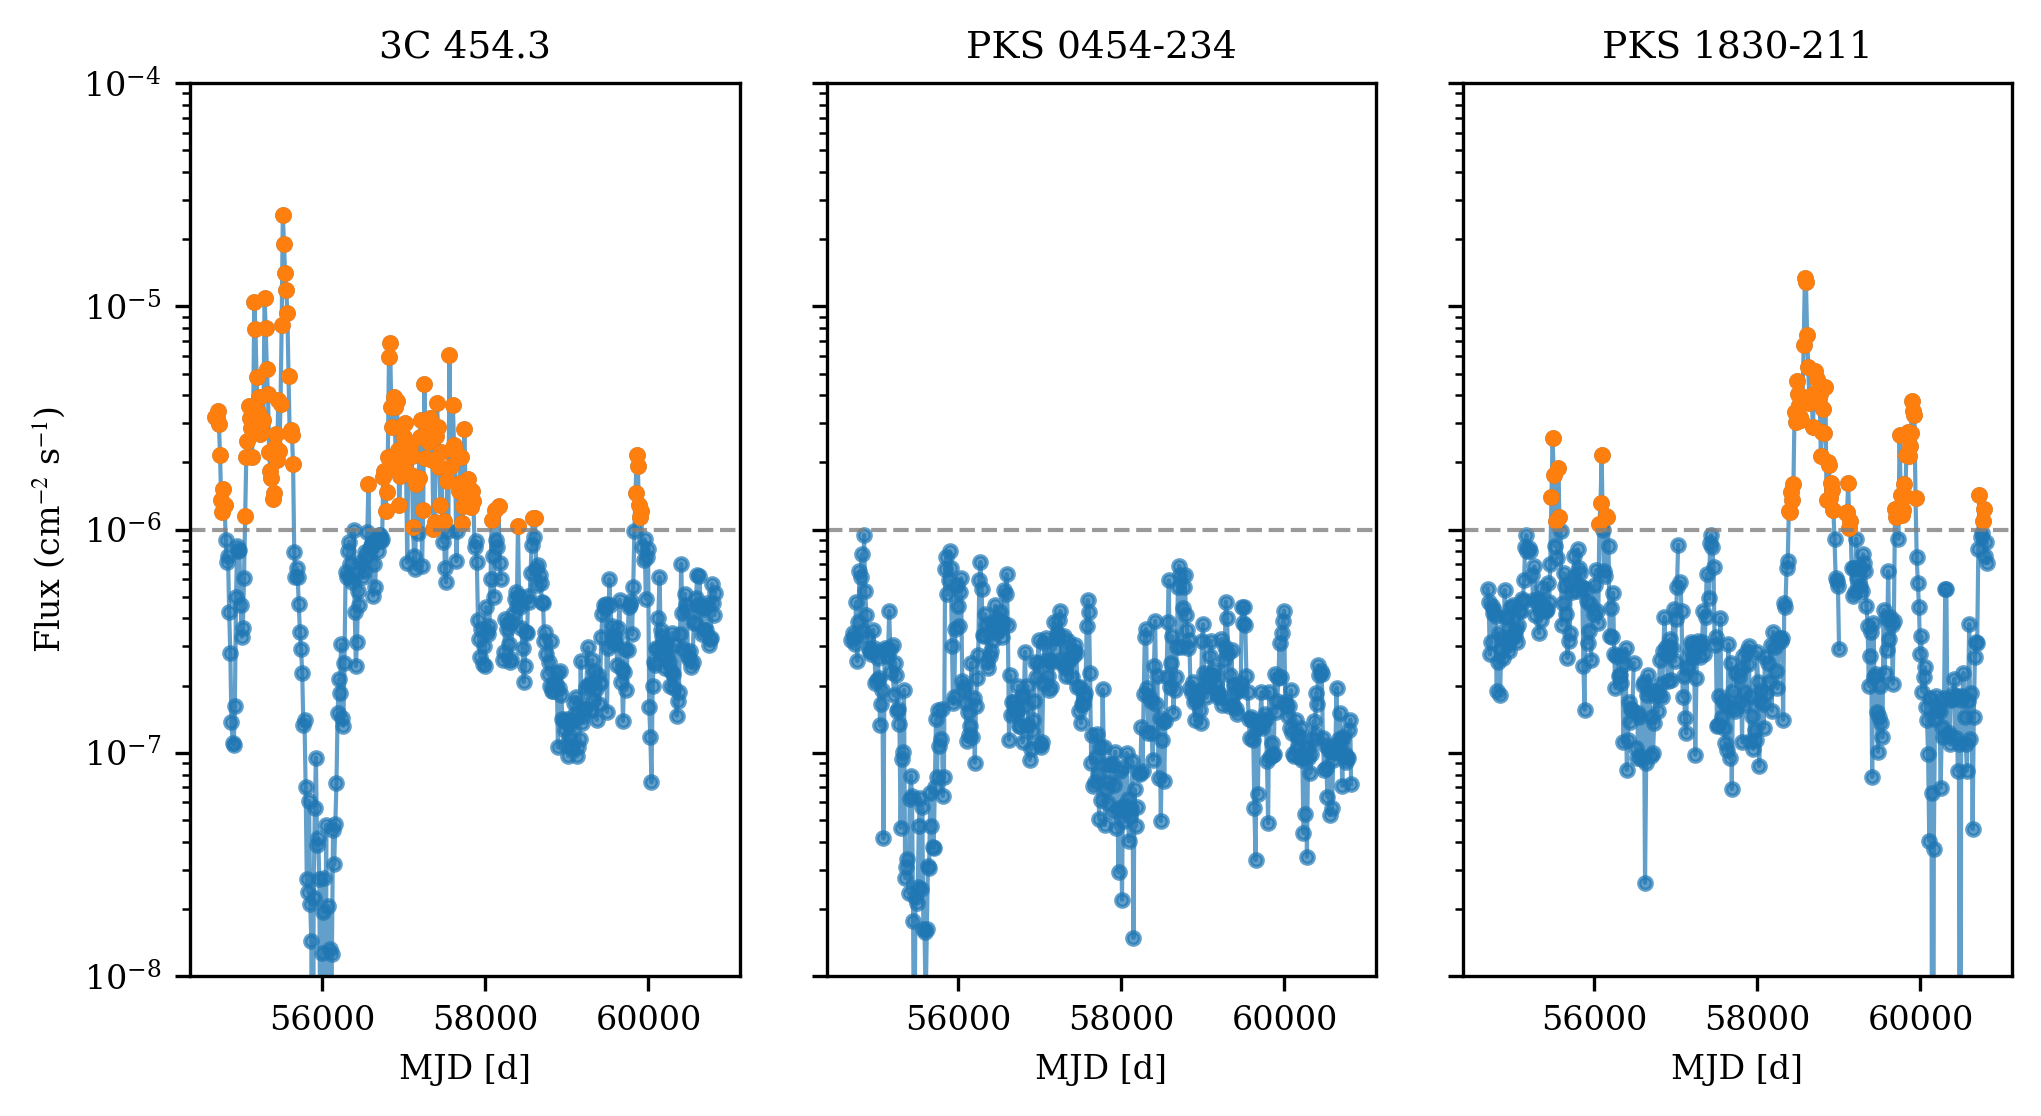

In [24]:
import matplotlib.pyplot as plt
from astropy.table import Table
import os

# Set rcParams for A&A style
# For the axes, the default font size is 10, but we can adjust it for better readability.
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16, # But it doesn't seem to work
    'axes.labelsize': 8,#10,
    'axes.titlesize': 8,#10,
    'xtick.labelsize': 10,#8,
    'ytick.labelsize': 10,#8,
    'legend.fontsize': 10,#8,
    'figure.titlesize': 10, #12,
    'mathtext.fontset': 'stix',  # For LaTeX-like math
    'figure.dpi': 300
})

# A&A single column width: 8.8 cm ≈ 3.46 inches
# For three panels, total width: 18 cm (double column) ≈ 7.09 inches
# Height: 6 inches for good aspect ratio
# fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 6), sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 4), sharey=True)

threshold_flux = 1.0e-6

# Select three brightest sources (indices 0, 4, 6)
selected_sources = dict_sourcename[[0, 10, 18]]

lc_file_dir = 'data_LC/14d'

for i, source in enumerate(selected_sources):
    ax = axes[i]
    sourcename_4fgl = source['4FGL name']
    lc_filepath = os.path.join(lc_file_dir, sourcename_4fgl + '_lightcurve.fits')
    
    if os.path.exists(lc_filepath):
        lc_tab = Table.read(lc_filepath)
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        
        mask = (lc_tab['flux'] > threshold_flux)
        
        # # Plot full light curve (second in legend)
        # ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        # # get the color of the full light curve line
        # lc_line_color = ax.get_lines()[0].get_color()
        # # Plot high state points (first in legend) 
        # # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=4,  markerfacecolor=lc_line_color, markeredgecolor='orange', linestyle='', label='High State')
        # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=4,  markeredgecolor=lc_line_color, linestyle='', label='High State')

        # get the colors of the palette        
        # palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
        # print(palette[0], palette[1], palette[2])
        # # Plot full light curve (second in legend)
        # ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, markerfacecolor=palette[0],markeredgecolor=palette[0], linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        # # get the color of the full light curve line
        # # Plot high state points (first in legend) 
        # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=3,  markerfacecolor=palette[0], markeredgecolor=palette[1], linestyle='', label='High State')
        # ax.scatter(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', color= palette[0],edgecolor = palette[1], s=12, linewidth=1, label='High State')
        # ax.scatter(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', color= palette[1], s=12, label='High State')

        ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=3, linestyle='', label='High State')
                
        # Threshold line
        ax.axhline(y=threshold_flux, color='gray', linestyle='--', linewidth=1, alpha=0.8)
        
        # Labels and limits
        ax.set_xlabel('MJD [d]')
        if i == 0:
            ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)')
        ax.set_yscale('log')
        ax.set_ylim(1e-8, 1e-4)
        ax.set_title(f"{source['assoc name for drawing']}", fontsize=9)# ({source['index']})", fontsize=10)
        handles, labels = ax.get_legend_handles_labels()
        # ax.legend(reversed(handles), reversed(labels), fontsize=8)#, loc='upper left')  # reverse to keep order consistent
        # ax.legend(loc='upper right', fontsize=8)
        
        # update the font size of values on the ticks to 10
        # Adjust tick parameters
        ax.tick_params(axis='both', which='major', labelsize=8)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("figures/Fig1_three_examples_aanda.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/Fig1_three_examples_aanda.pdf", dpi=300, bbox_inches='tight')  # Also save as PDF for Overleaf

plt.show()

# Fig.1 変更
  - 描画するのは
    - 3C454.3 14d, SED描画可能点をハイライト
    - 3C454.3  1d, SED描画可能点をハイライト
    - PKS1830 14d, SED描画可能点をハイライト, 1e-6ラインの追加 
  - 各図タイトル
    - 天体名, 時間窓


### - LC ファイル読込
### - SED ecsv ファイル読込
### - 存否検索・列追加
### - 描画

4fgl_j2253.9+1609
4fgl_j2253.9+1609
4fgl_j1833.6-2103
ValidSED       t_mjd       ...  dnde10000_index   dnde10000_index_fixed
                 d         ...                                         
-------- ----------------- ... ------------------ ---------------------
    True 54689.65603222222 ... 3.2370388861748274     3.178218648905218
    True 54703.65603222222 ...  3.108980794310082     3.178218648905218
    True 54717.65603222222 ... 3.0465421043034104     3.178218648905218
    True 54731.65603222222 ... 3.3102625725636012     3.178218648905218
    True 54745.65603222222 ...  3.098045795217661     3.178218648905218
    True 54759.65603222222 ...  2.960508398502115     3.178218648905218
    True 54773.65603222222 ... 3.6387833705453563     3.178218648905218
    True 54787.65603222222 ... 3.7422122887326883     3.178218648905218
    True 54801.65603222222 ... 3.9408130736913853     3.178218648905218
    True 54815.65603222222 ...  3.205477862764082     3.178218648905218
     ...  

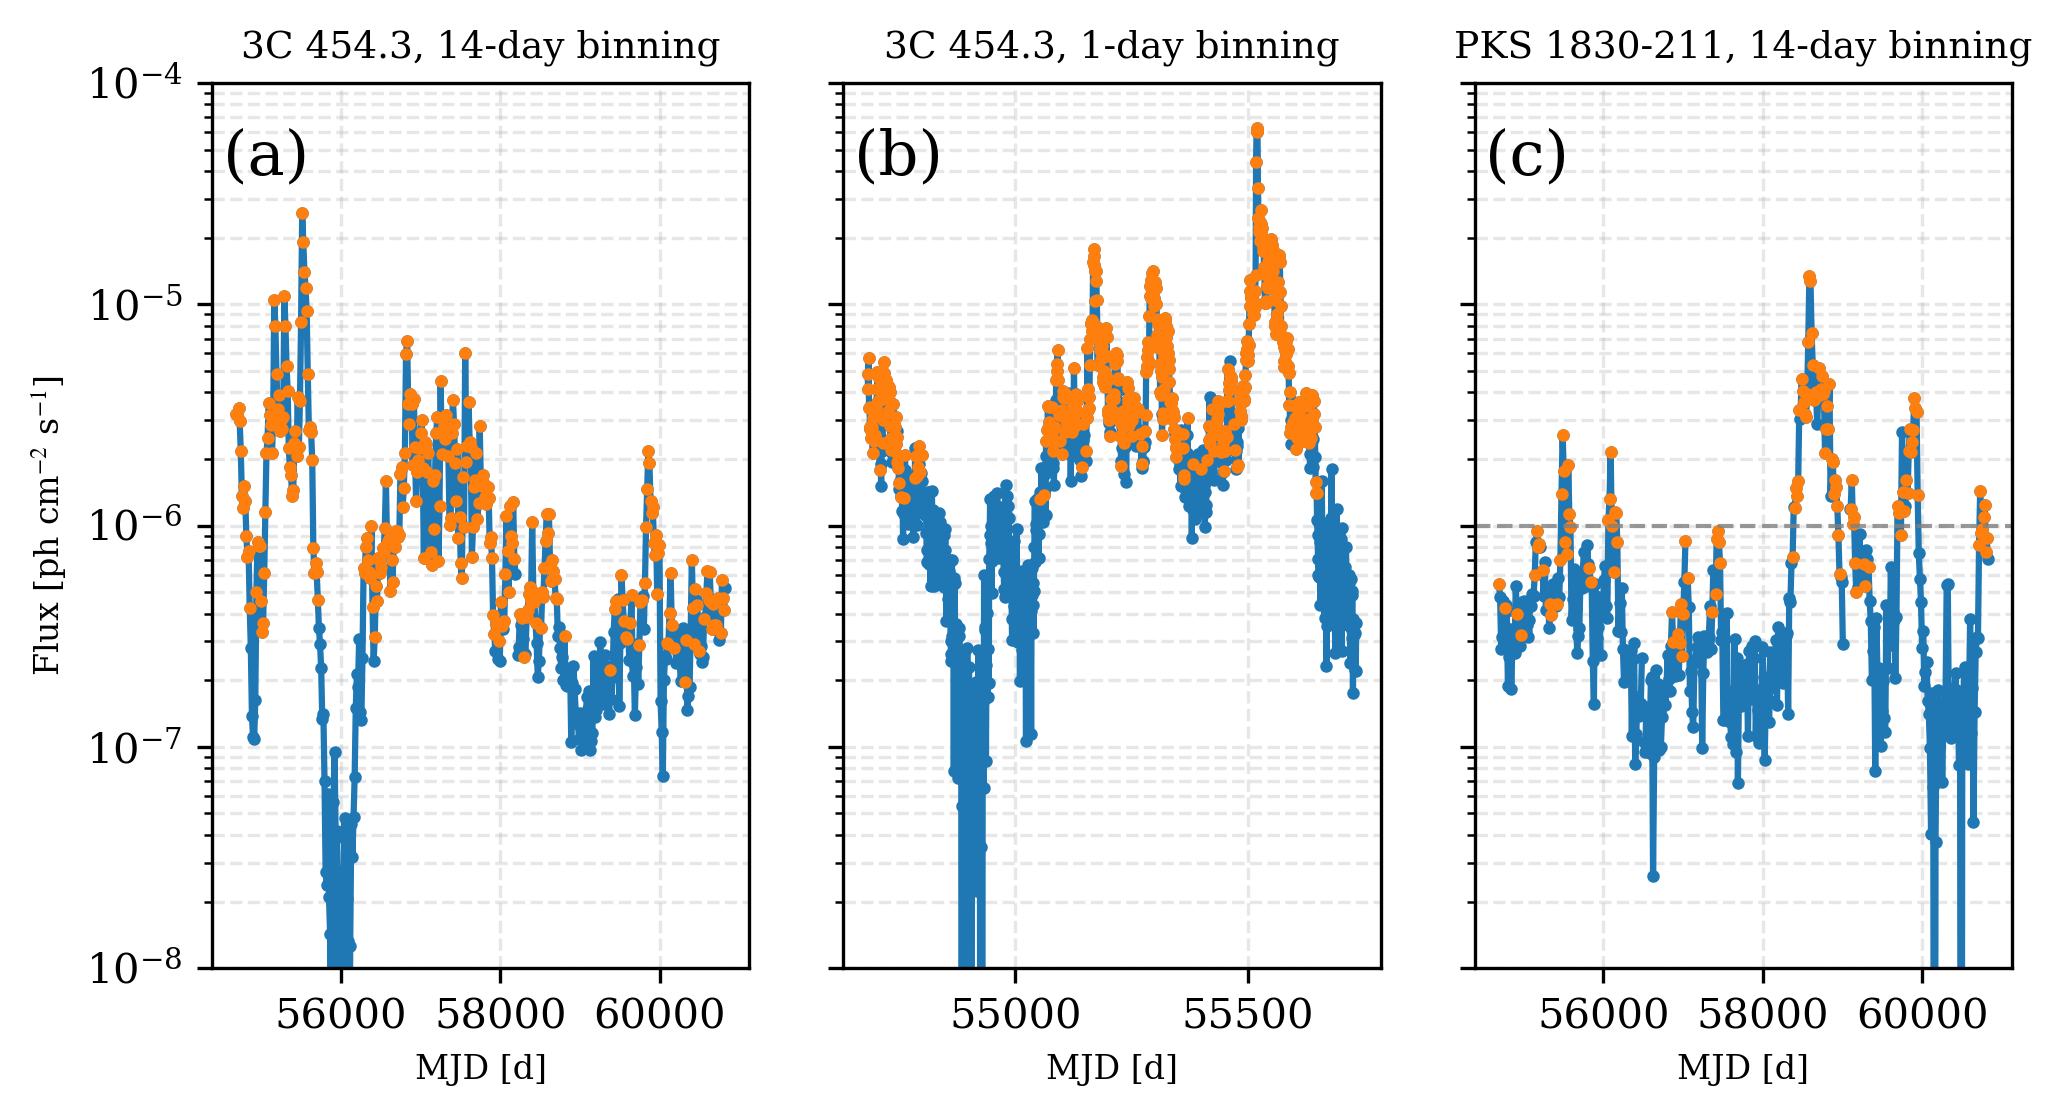

In [66]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os


# LC
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve1.fits') # first 1050 days
# file paths are data_LC/14d/4gl_XXXX_lightcurve.fits, where XXX is the 4FGL name of the source.
#  in case 1d, data_LC/1d/4gl_XXXX_lightcurve1.fits

# For one day
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve1.fits') # first 1050 days
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve2.fits') # second high state of 1150 days
# lc_tab = Table.read(lc_filepath)

# # SED
# sed_filepath = 'data/3C454.3_allsed_1d_min11.ecsv' # both periods



t_plot= Table(names = 
              ('figlabel', 'index', 'assoc name', 
              #  '4FGL name', 'assoc name for SEDfile', 'assoc name for drawing',
               'dayscale','dayscale for drawing', 'lc_filepath','sed_filepath'),
              dtype = ('U10', 'i4', 'U20',  
                      #  'U20',  'U20',  'U20', 
                       'U10', 'U10', 'U100', 'U100')
              )

# drawing candidates


t_plot.add_row(('(a)',0, '3c_454.3',     '14', "14-day binning", "", ""))
t_plot.add_row(('(b)',1, '3c_454.3',     '1',   "1-day binning", "", ""))#, 'data_LC/1d/3C454.3_lightcurve1.fits', 'data/3C454.3_allsed_1d_1_min11.ecsv'))
t_plot.add_row(('(c)',2,'pks_1830-211', '14', "14-day binning", "", ""))

# Add colums for '4FGL name', 'assoc name for SEDfile', 'assoc name for drawing',
t_plot.add_column(["---------- not assigned ----------"]*len(t_plot), name='4FGL name', index=2)
t_plot.add_column(["---------- not assigned ----------"]*len(t_plot), name='assoc name for SEDfile', index=3)
t_plot.add_column(["---------- not assigned ----------"]*len(t_plot), name='assoc name for drawing', index=4)
for idx in range(len(t_plot)):
  print(dict_sourcename[dict_sourcename['assoc name'] == t_plot[idx]['assoc name']]['4FGL name'].data[0])
  t_plot[idx]['4FGL name'] = dict_sourcename[dict_sourcename['assoc name'] == t_plot[idx]['assoc name']]['4FGL name'].data[0]
  t_plot[idx]['assoc name for SEDfile'] = dict_sourcename[dict_sourcename['assoc name'] == t_plot[idx]['assoc name']]['assoc name for SEDfile'].data[0]
  t_plot[idx]['assoc name for drawing'] = dict_sourcename[dict_sourcename['assoc name'] == t_plot[idx]['assoc name']]['assoc name for drawing'].data[0]

### lc_filepath = data_LC/14d/4fgl_j2254.0+1608_lightcurve.fits
t_plot[0]['lc_filepath'] = 'data_LC/' + t_plot[0]['dayscale'] + 'd/' + t_plot[0]['4FGL name'] + '_lightcurve.fits'
t_plot[1]['lc_filepath'] = 'data_LC/' + t_plot[1]['dayscale'] + 'd/' + t_plot[1]['4FGL name'] + '_lightcurve1.fits' # first 1050 days
t_plot[2]['lc_filepath'] = 'data_LC/' + t_plot[2]['dayscale'] + 'd/' + t_plot[2]['4FGL name'] + '_lightcurve.fits'

### sed_filepath = data/3C454.3_allsed_1d_min11.ecsv
t_plot[0]['sed_filepath'] = 'data/' + t_plot[0]['assoc name for SEDfile'] + '_allsed_' + t_plot[0]['dayscale'] + 'd_min11.ecsv'
t_plot[1]['sed_filepath'] = 'data/' + t_plot[1]['assoc name for SEDfile'] + '_allsed_' + t_plot[1]['dayscale'] + 'd_min11.ecsv'
t_plot[2]['sed_filepath'] = 'data/' + t_plot[2]['assoc name for SEDfile'] + '_allsed_' + t_plot[2]['dayscale'] + 'd_min11.ecsv'
t_plot

# ###########################
# ### Read the data       ###
# ###########################
# Set rcParams for A&A style
# For the axes, the default font size is 10, but we can adjust it for better readability.
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16, # But it doesn't seem to work
    'axes.labelsize': 8,#10,
    'axes.titlesize': 8,#10,
    'xtick.labelsize': 10,#8,
    'ytick.labelsize': 10,#8,
    'legend.fontsize': 10,#8,
    'figure.titlesize': 10, #12,
    'mathtext.fontset': 'stix',  # For LaTeX-like math
    'figure.dpi': 300
})

# A&A single column width: 8.8 cm ≈ 3.46 inches
# For three panels, total width: 18 cm (double column) ≈ 7.09 inches
# Height: 6 inches for good aspect ratio
# fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 6), sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 4), sharey=True)

for i, source in enumerate(t_plot):
    ax = axes[i]
    lc_filepath = source['lc_filepath']
    
    if os.path.exists(lc_filepath):
      lc_tab = Table.read(lc_filepath)
      lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)

      
      # SED
      sed_filepath = source['sed_filepath']
      if os.path.exists(sed_filepath):
        sed_tab_0 = Table.read(sed_filepath)
        nonzero_mask = (sed_tab_0['e2dnde'] > sed_tab_0['e2dnde_err'])
        sed_tab = sed_tab_0[nonzero_mask]
        ###########################
        ###    データ整形         ###
        ###########################
        obsdates_sed=np.round(np.unique(sed_tab['tstart'].data).tolist())
        obsdates_lc=np.round(lc_tab['tmin_mjd'])
        array_validseds = []
        for idx, obsdate_lc in enumerate(obsdates_lc):
          # print(idx, ': obsdate',obsdate_lc)
          mask = (obsdates_sed==obsdate_lc)
          if mask.sum() > 0:
            # print('obsdate', obsdate_lc, '---', mask.sum() )
            # print(lc_tab[idx])
            array_validseds.append(True)
          else:
            # print('obsdate', obsdate_lc)
            array_validseds.append(False)
        from astropy.table import Column
        lc_tab.add_column(array_validseds, name='ValidSED', index=0)
        print(lc_tab)

        ### Light Curve ###
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']
        ax.plot(lc_x,lc_y ,marker='o', markersize=2,label="Full Light Curve")

        mask = (lc_tab['ValidSED'] == True)
        lc_x=lc_tab[mask]['t_mjd']
        lc_y=lc_tab[mask]['flux']
        ax.plot(lc_x,lc_y ,marker='o', markersize=2, linestyle='', label="Valid SEDs")

      else:
        ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=2, linestyle='-', linewidth=1, alpha=0.7, label='Full LC')

      # Labels and limits
      ax.set_xlabel('MJD [d]')
      if i == 0:
          ax.set_ylabel(r'Flux [ph cm$^{-2}$ s$^{-1}$]')
      if i == 2:
        # Threshold line
        ax.axhline(y=threshold_flux, color='gray', linestyle='--', linewidth=1, alpha=0.8)
        
      ## add figlabel (like text (a), (b), (c), ...) at the top left corner of the plot
      ax.text(0.02, 0.95, source['figlabel'], transform=ax.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left')
      # ax.text(0.02, 0.95, source['figlabel'], transform=plt.gca().transAxes, fontsize=15, verticalalignment='top') 

      ax.set_yscale('log')
      ax.set_ylim(1e-8, 1e-4)
      ax.set_title(f"{source['assoc name for drawing']}, {source['dayscale for drawing']}", fontsize=9)# ({source['index']})", fontsize=10)
      
      # handles, labels = ax.get_legend_handles_labels()
  
      ax.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

# save figure for A&A
plt.tight_layout()
plt.savefig("figures/Fig1_three_examples_aanda.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/Fig1_three_examples_aanda.pdf", dpi=300, bbox_inches='tight')  # Also save as PDF for Overleaf
plt.show()
